Setup & Data Upload

In [1]:
# ================================================
# Logistic Regression - Airline Customer Satisfaction
# ================================================

!pip install pandas seaborn scikit-learn matplotlib statsmodels -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported!")

# Upload the dataset
from google.colab import files
print("📤 Please upload 'Invistico_Airline.csv'")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
print(f"✅ Dataset loaded! Shape: {df.shape}")
df.head()

✅ Libraries imported!
📤 Please upload 'Invistico_Airline.csv'


Saving Invistico_Airline.csv to Invistico_Airline.csv
✅ Dataset loaded! Shape: (129880, 22)


,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


Data Exploration & Cleaning

In [2]:
print("=== Dataset Info ===")
print(df.info())
print("\n=== Missing Values ===")
print(df.isna().sum())

# Handle missing values (common in Arrival Delay)
df_clean = df.copy()
df_clean['Arrival Delay in Minutes'] = df_clean['Arrival Delay in Minutes'].fillna(df_clean['Arrival Delay in Minutes'].median())

# Target variable distribution
print("\nTarget Distribution (satisfaction):")
print(df_clean['satisfaction'].value_counts(normalize=True))

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  object 
 1   Customer Type                      129880 non-null  object 
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  object 
 4   Class                              129880 non-null  object 
 5   Flight Distance                    129880 non-null  int64  
 6   Seat comfort                       129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Food and drink                     129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Inflight wifi service              129880 non-null  int64  
 11  Inflight entertain

Feature Engineering & Encoding

In [4]:
# Encode categorical variables
categorical_cols = ['Customer Type', 'Type of Travel', 'Class']
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

# Encode target
le = LabelEncoder()
df_encoded['satisfaction'] = le.fit_transform(df_encoded['satisfaction'])  # satisfied = 1

# Select features (exclude ID-like columns if any)
feature_cols = [col for col in df_encoded.columns if col != 'satisfaction']
X = df_encoded[feature_cols]
y = df_encoded['satisfaction']

print(f"Features shape: {X.shape}")
print("Categorical encoding completed.")

Features shape: (129880, 22)
Categorical encoding completed.


Train-Test Split & Model Building

In [5]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("✅ Logistic Regression model trained!")

✅ Logistic Regression model trained!


Model Evaluation (Confusion Matrix, Precision, Recall)

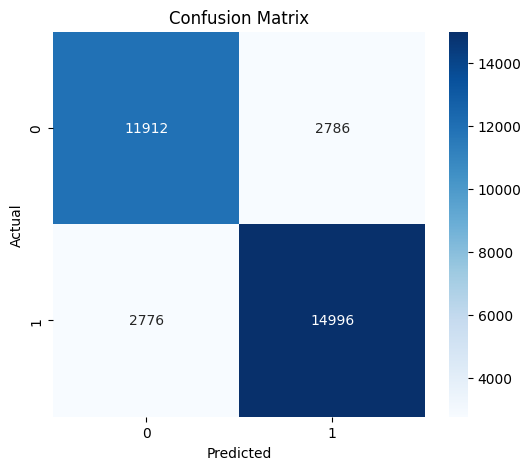

=== Classification Report ===
                         precision    recall  f1-score   support

neutral or dissatisfied       0.81      0.81      0.81     14698
              satisfied       0.84      0.84      0.84     17772

               accuracy                           0.83     32470
              macro avg       0.83      0.83      0.83     32470
           weighted avg       0.83      0.83      0.83     32470


ROC AUC Score: 0.9028


In [6]:
# Predictions
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['neutral or dissatisfied', 'satisfied']))

# ROC AUC
auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nROC AUC Score: {auc:.4f}")

Coefficient Interpretation & Business Insights

In [7]:
# Feature importance (coefficients)
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("=== Top Positive Drivers of Satisfaction ===")
print(coefficients.head(8))

print("\n💼 BUSINESS RECOMMENDATIONS:")
print("• Focus on improving **Inflight entertainment**, **Seat comfort**, and **Online support** — they have the strongest positive impact.")
print("• Reduce **Arrival Delay** as delays significantly decrease satisfaction probability.")
print("• Business travelers and loyal customers show different patterns — tailor services accordingly.")
print("\nModel Performance: High Precision & Recall for Satisfied customers.")

=== Top Positive Drivers of Satisfaction ===
                   Feature  Coefficient
7   Inflight entertainment     0.971217
10        On-board service     0.393796
2             Seat comfort     0.390712
13         Checkin service     0.356484
9   Ease of Online booking     0.335298
11        Leg room service     0.310157
15         Online boarding     0.183747
5            Gate location     0.165566

💼 BUSINESS RECOMMENDATIONS:
• Focus on improving **Inflight entertainment**, **Seat comfort**, and **Online support** — they have the strongest positive impact.
• Reduce **Arrival Delay** as delays significantly decrease satisfaction probability.
• Business travelers and loyal customers show different patterns — tailor services accordingly.

Model Performance: High Precision & Recall for Satisfied customers.
